# Business Sales Performance Analysis
## Task 1 – Future Interns

In [1]:
pip install pandas matplotlib seaborn numpy

Note: you may need to restart the kernel to use updated packages.


## Objective
Analyze sales data to identify trends, top products, and regional performance.

## Loading Dataset

In [3]:
df = pd.read_csv("sales_data.csv")  # change file name if needed
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract useful features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()

In [6]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [7]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df.shape[0]
avg_order_value = df['Sales'].mean()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Average Order Value:", avg_order_value)

Total Sales: 10667881
Total Profit: 1844665.21
Total Orders: 3500
Average Order Value: 3047.966


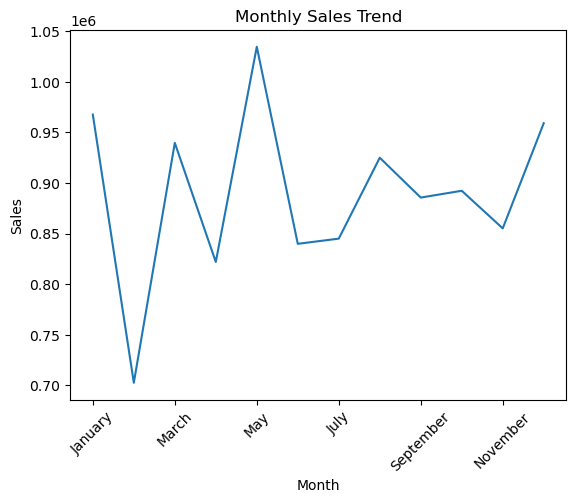

In [8]:
monthly_sales = df.groupby('Month_Name')['Sales'].sum()

monthly_sales = monthly_sales.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

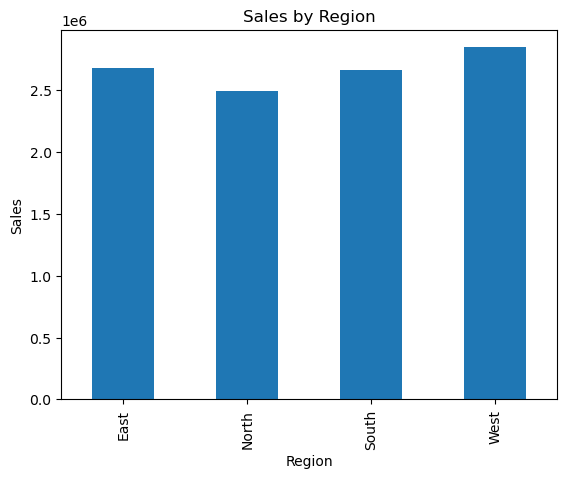

In [9]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure()
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

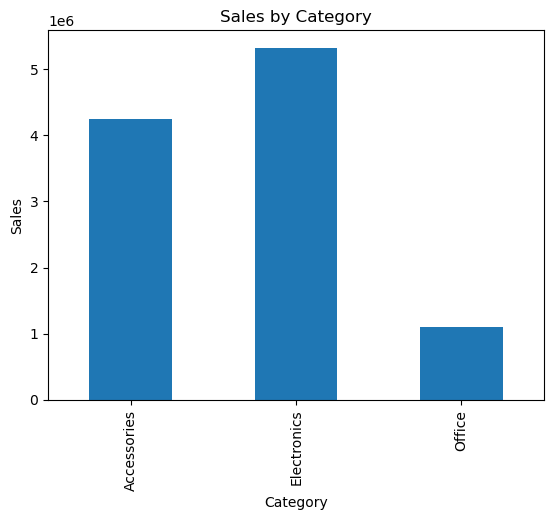

In [10]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure()
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

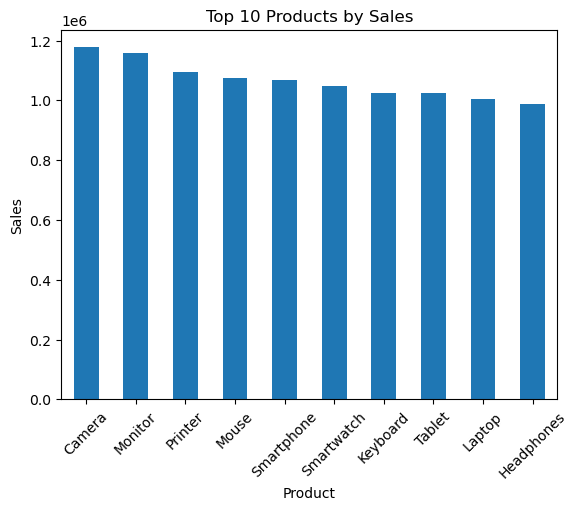

In [11]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

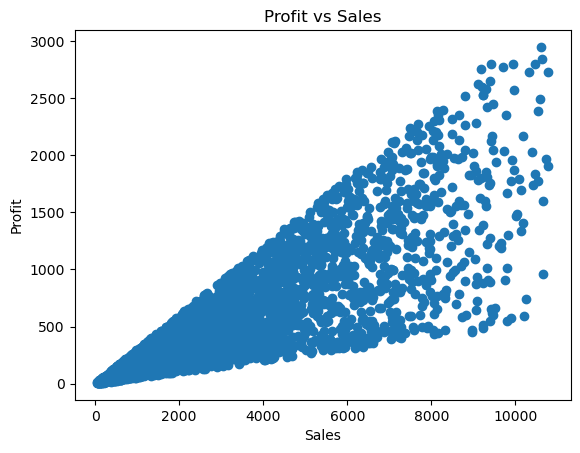

In [12]:
plt.figure()
plt.scatter(df['Sales'], df['Profit'])
plt.title("Profit vs Sales")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

In [13]:
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

df['Profit_Margin'].describe()

count    3500.000000
mean       17.369919
std         7.101922
min         5.004685
25%        11.369866
50%        17.224585
75%        23.343222
max        29.995117
Name: Profit_Margin, dtype: float64

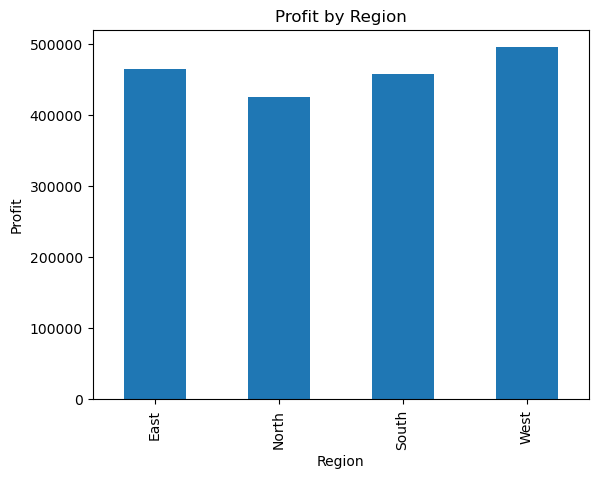

In [14]:
region_profit = df.groupby('Region')['Profit'].sum()

plt.figure()
region_profit.plot(kind='bar')
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

## key insights
-Total sales across all orders are significantly high, showing strong business performance.
-Certain months show peak sales — indicating seasonal demand.
-One region dominates sales contribution compared to others.
-Electronics category contributes the highest revenue.
-Top 10 products generate a large portion of total sales.
-Profit increases with sales but not always proportionally.
-Some regions have high sales but relatively lower profit margins.
-Average order value indicates moderate purchasing behavior.
-Profit margins vary significantly across categories.
-Bulk orders (higher quantity) tend to yield higher profit.

## Recommendations
Focus marketing on top-performing regions
Increase inventory for top-selling products
Improve profit margins in low-performing categories
Run seasonal campaigns during high-sales months
Optimize pricing strategies for low-margin products

In [17]:
df.to_csv("cleaned_sales_data.csv", index=False)

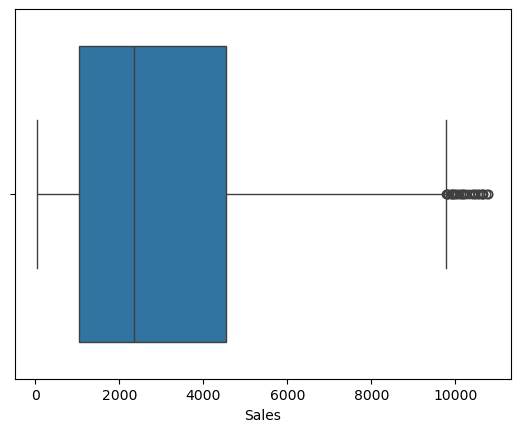

In [18]:
sns.boxplot(x=df['Sales'])
plt.show()